In [1]:
# pip install seaborn

In [2]:
import pandas as pd
df = pd.read_csv('world_development_data.csv')
df.head()

,Year,Country,Region,SubRegion,SurfAreaSqKm,PopTotal,PopDens,PopGrowth%,GDP,GDPGrowth%,...,GNIAtlas,Imports%GDP,IndValAdd%GDP,InflConsPric%,LifeExpBirth,MerchTrade%GDP,MobileSubs/100,MortRateU5,NetMigr,UrbanPopGrowth%
0,2000.0,Afghanistan,Asia,Southern Asia,652860.0,19542982.0,29.963329,1.443803,1.801248e+10,-5.206288,...,1.778669e+10,41.312634,17.178775,37.611028,55.298000,52.777048,0.000000,129.3,-1007135.0,1.861377
1,2000.0,Malta,Europe,Southern Europe,320.0,390087.0,1219.021875,0.645267,4.323339e+09,19.681791,...,4.273280e+09,128.374581,26.939987,-4.512396,78.348780,135.682159,28.667475,7.6,1799.0,0.952299
2,2000.0,Belgium,Europe,Western Europe,30530.0,10251250.0,338.548547,0.242518,2.367925e+11,3.716679,...,2.654129e+11,69.682740,24.943833,2.014617,77.721951,154.515900,54.840339,5.9,32262.0,0.308431
3,2000.0,Marshall Islands,Oceania,Micronesia,180.0,54224.0,301.244444,0.721838,1.153475e+08,1.354079,...,1.500075e+08,100.812761,12.681072,-0.454689,63.275000,55.484514,0.824358,42.1,-1323.0,1.492787
4,2000.0,Mauritania,Africa,Sub-Saharan Africa,1030700.0,2695003.0,2.614731,2.799182,1.779521e+09,-3.918026,...,1.907497e+09,33.423259,29.951850,6.351587,61.028000,45.461676,0.567717,98.8,-2997.0,2.476860


In [3]:
# keep only data in year 2021 and the following columns only [PopGrowth%, GDPGrowth%, UrbanPopGrowth%]
df=df.loc[df.Year == 2021, ['PopGrowth%', 'GDPGrowth%', 'UrbanPopGrowth%']]

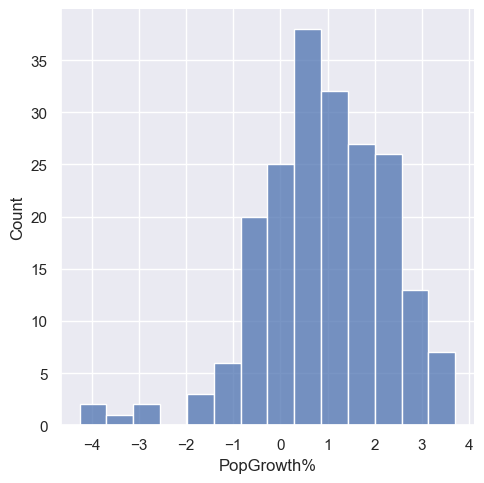

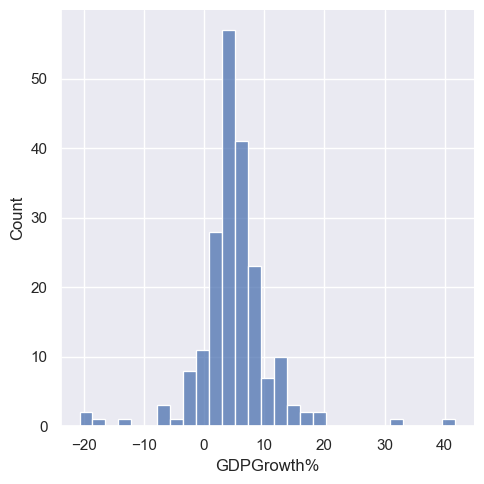

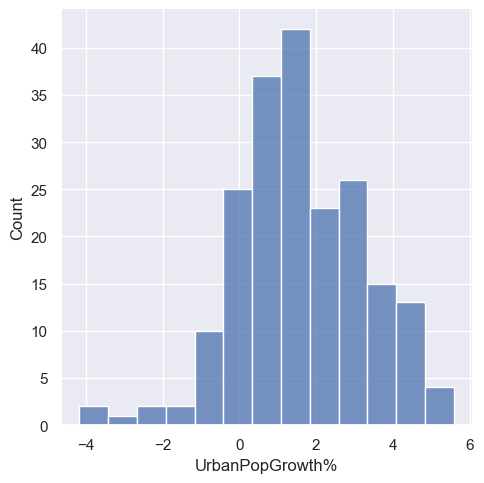

In [4]:
# Plot each column distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(rc={'figure.figsize':(10,10)})
sns.displot(df['PopGrowth%'])
sns.displot(df['GDPGrowth%'])
sns.displot(df['UrbanPopGrowth%'])

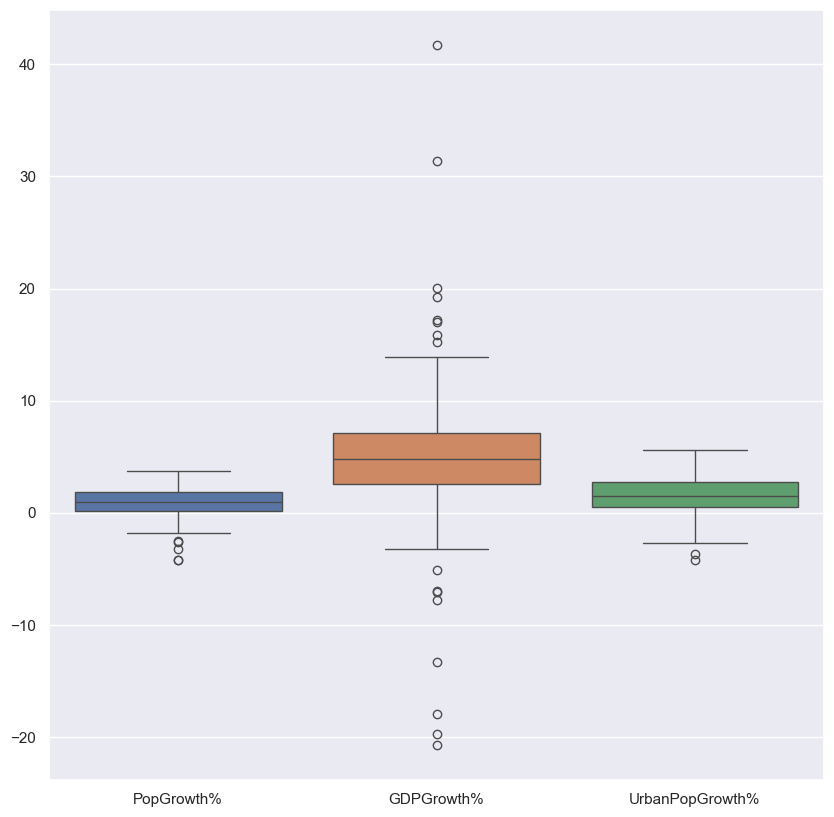

In [5]:
sns.boxplot(data=df);

In [6]:
# Exclude outliers
import numpy as np
df=df[df.apply(lambda x: np.abs(x - x.mean()) / x.std() < 3).all(axis=1)]

Text(0, 0.5, 'Error')

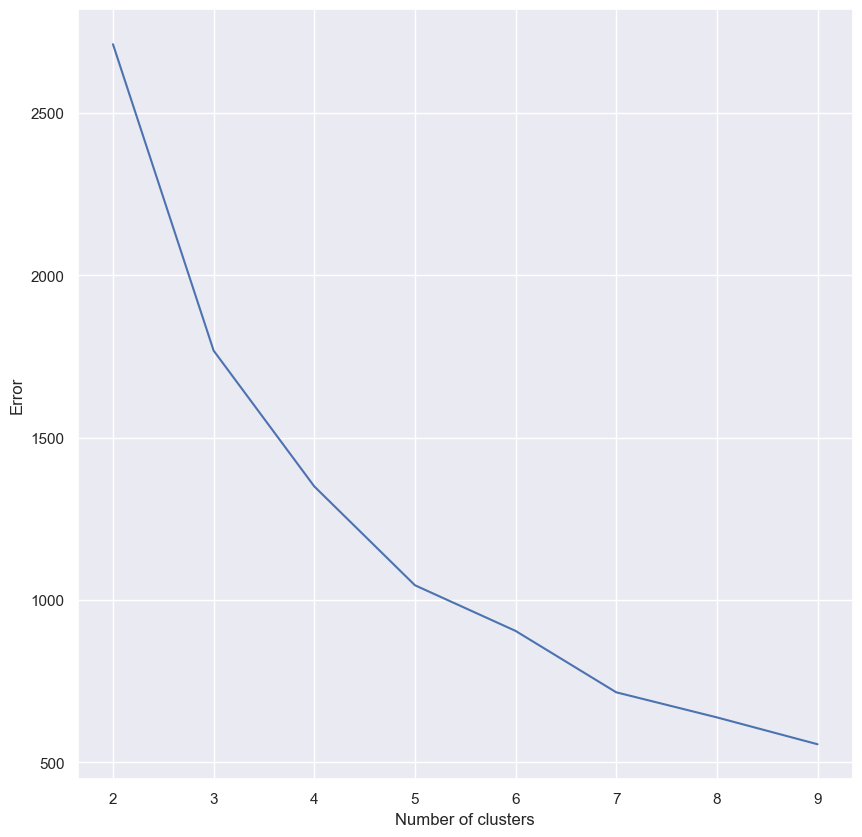

In [7]:
# Find the optimal number of clusters
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
X=df.values
errors=[]
for i in range(2,10):
  kmeans=KMeans(n_clusters=i)
  kmeans.fit(X)
  errors.append(kmeans.inertia_)

plt.plot(range(2,10),errors)
plt.xlabel('Number of clusters')
plt.ylabel('Error')

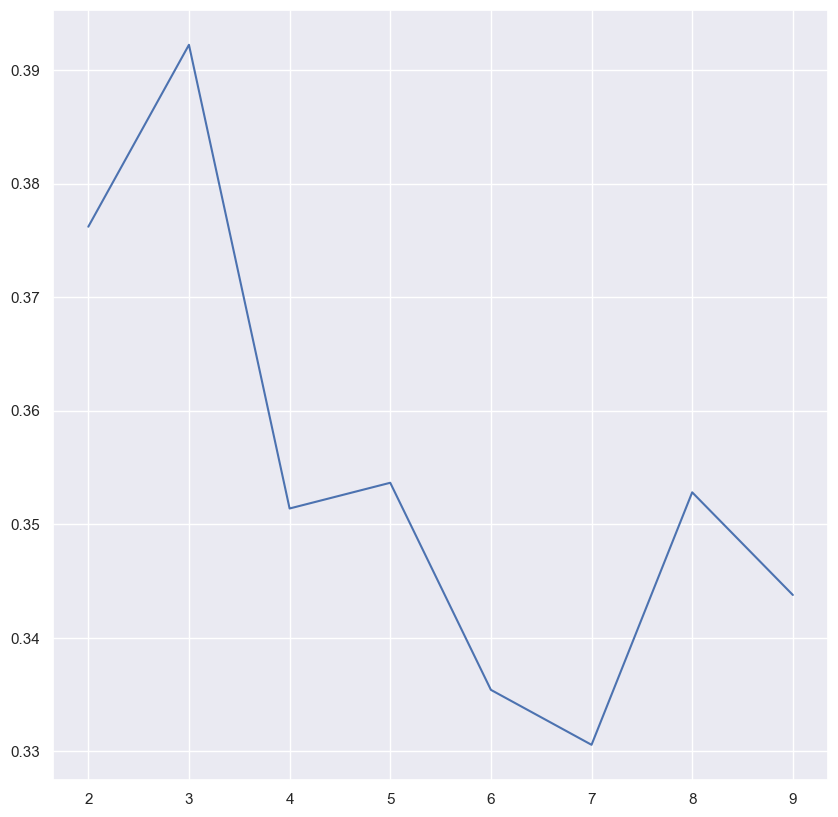

In [8]:
# using silhoutte score
from sklearn.metrics import silhouette_score
scores=[]
for i in range(2,10):
  kmeans=KMeans(n_clusters=i)
  kmeans.fit(X)
  scores.append(silhouette_score(X,kmeans.labels_))

plt.plot(range(2,10),scores)

In [9]:
# Choose the optimal number of clusters and apply K-Means clustering
kmeans=KMeans(n_clusters=3)
kmeans.fit(X)
df['cluster']=kmeans.labels_

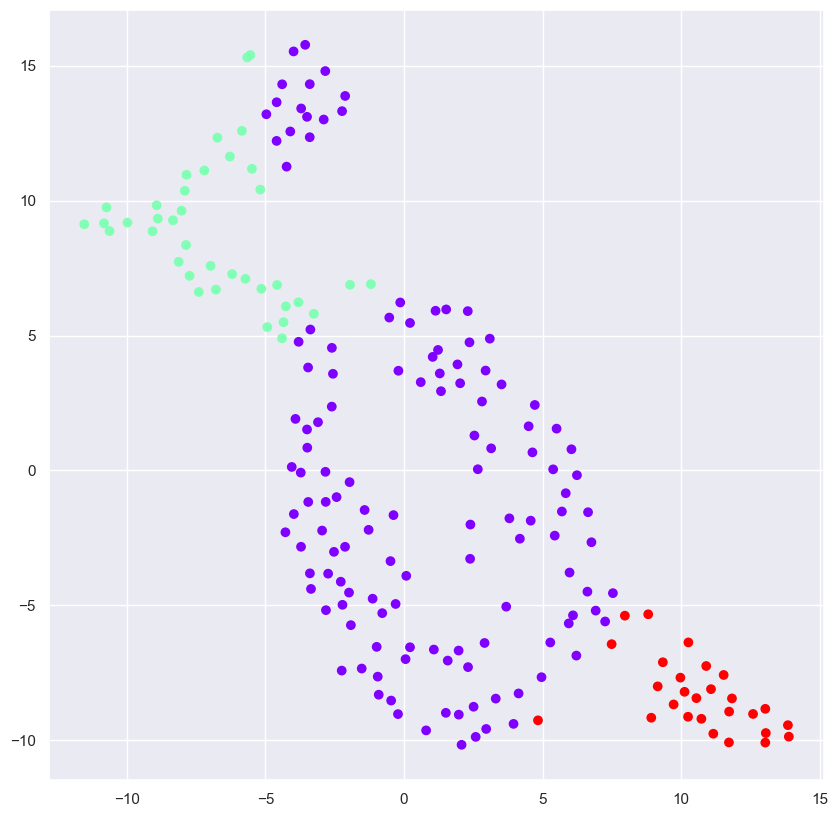

In [10]:
# Plot the clusters and explain your findings
# use t-sne to reduce the number of dimension
import numpy as np
from sklearn.manifold import TSNE
tsne=TSNE(n_components=2)
new_data=tsne.fit_transform(X)
plt.scatter(new_data[:,0],new_data[:,1],c=df['cluster'], cmap='rainbow')
#

In [11]:
df.head()

,PopGrowth%,GDPGrowth%,UrbanPopGrowth%,cluster
4242,2.137790,4.792027,3.806804,0
4243,0.844182,2.561551,2.733031,0
4244,2.457039,7.011982,2.826525,0
4245,-0.082447,5.276559,0.009648,0
4246,2.840806,4.598734,4.094430,0


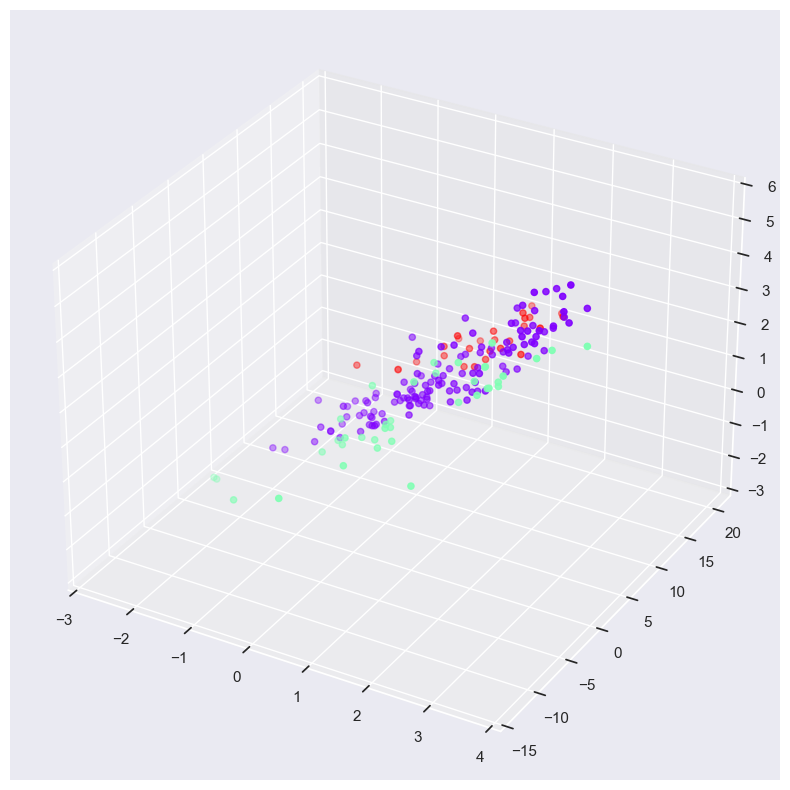

In [12]:
# use scatter3D to plot data in 3d
plt.figure(figsize=(10,10))
ax=plt.axes(projection='3d')
ax.scatter3D(df.iloc[:,0],df.iloc[:,1],df.iloc[:,2],c=df['cluster'],cmap='rainbow')

